# 02. Network Construction and Core Features

Build the signed directed multigraph and inspect graph, node, and pair-level feature tables.

In [1]:
from pathlib import Path
import sys

root = Path.cwd()
if not (root / 'data').exists():
    root = root.parent
sys.path.insert(0, str(root))

from src.phase2 import build_edge_feature_table, build_node_feature_table, build_signed_multidigraph, load_phase1_filtered

phase1_path = root / 'data' / 'processed' / 'phase1_kcore_filtered.csv'
phase1_path

WindowsPath('H:/chuong_trinh_hoc_UEH/mon_hoc_ki_6/social_media_data_analysis/Project/Explainable_Signed_Link_Prediction_for_Reddit_Inter-Community_Conflict_Warning/data/processed/phase1_kcore_filtered.csv')

In [2]:
frame = load_phase1_filtered(phase1_path)
graph = build_signed_multidigraph(frame)
node_features = build_node_feature_table(graph)
edge_features = build_edge_feature_table(frame, graph)

{
    'rows': len(frame),
    'nodes': graph.number_of_nodes(),
    'edges': graph.number_of_edges(),
    'node_feature_rows': len(node_features),
    'edge_feature_rows': len(edge_features),
}

{'rows': 708425,
 'nodes': 12968,
 'edges': 708425,
 'node_feature_rows': 12968,
 'edge_feature_rows': 249441}

In [3]:
node_features.head()

,node,in_degree,out_degree,total_degree,in_positive_degree,in_negative_degree,out_positive_degree,out_negative_degree,pagerank,betweenness,reciprocity
0,agitation,7,198,205,7,0,163,26,0.000015,0.000091,0.029268
1,changemyview,552,186,738,510,33,140,36,0.001004,0.005669,0.203252
2,askreddit,3699,338,4037,3423,185,298,25,0.025866,0.053722,0.130295
3,economy,51,53,104,46,3,49,1,0.000074,0.000055,0.230769
4,todayilearned,2156,367,2523,1980,114,331,25,0.008475,0.032749,0.163298


In [4]:
edge_features.head()

,source_subreddit,target_subreddit,interaction_count,positive_count,negative_count,first_timestamp,last_timestamp,sentiment_balance,negative_ratio,reciprocal_edge
0,100daysofketo,bodyweightfitness,1,1,0,2016-01-05 23:14:30,2016-01-05 23:14:30,1,0.0,0
1,100daysofketo,documentaries,1,1,0,2016-04-27 18:43:26,2016-04-27 18:43:26,1,0.0,0
2,100daysofketo,keto,5,5,0,2015-02-19 08:03:09,2016-05-07 03:27:05,5,0.0,1
3,100daysofketo,loseit,1,1,0,2016-02-01 17:08:15,2016-02-01 17:08:15,1,0.0,0
4,100daysofketo,xxketo,2,2,0,2015-09-29 23:07:07,2016-01-12 07:23:33,2,0.0,1


## Direct Network Visualizations

The following chart summarizes the directed degree distribution after k-core filtering.

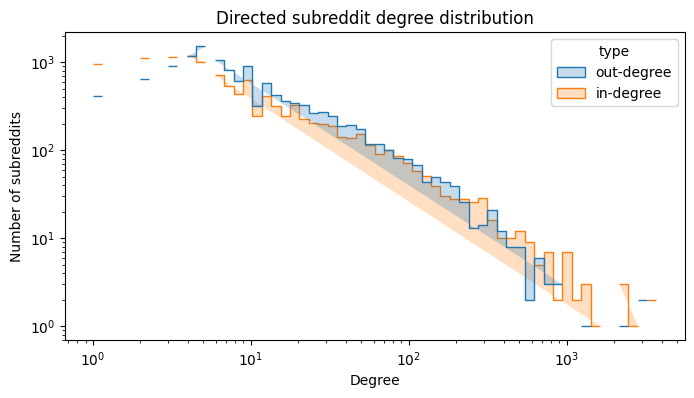

,node,in_degree,out_degree,total_degree,in_positive_degree,in_negative_degree,out_positive_degree,out_negative_degree,pagerank,betweenness,reciprocity
2,askreddit,3699,338,4037,3423,185,298,25,0.025866,0.053722,0.130295
30,iama,3318,372,3690,3190,86,365,4,0.022104,0.076003,0.156640
23,pics,2603,144,2747,2424,108,141,1,0.013769,0.014477,0.074263
12,funny,2325,409,2734,2108,140,378,22,0.012017,0.038707,0.182882
20,videos,2177,211,2388,1998,126,208,2,0.011596,0.020823,0.119765
4,todayilearned,2156,367,2523,1980,114,331,25,0.008475,0.032749,0.163298
24,worldnews,1468,143,1611,1281,126,137,6,0.007937,0.017056,0.125388
53,gaming,1395,646,2041,1290,64,635,5,0.006956,0.031684,0.334150
7,news,1367,224,1591,1158,139,218,5,0.006114,0.014713,0.172219
99,science,1215,72,1287,1140,54,72,0,0.005830,0.006299,0.073038


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

out_degree = frame.groupby('source_subreddit')['target_subreddit'].nunique()
in_degree = frame.groupby('target_subreddit')['source_subreddit'].nunique()
degree_frame = pd.concat([
    pd.DataFrame({'degree': out_degree, 'type': 'out-degree'}),
    pd.DataFrame({'degree': in_degree, 'type': 'in-degree'}),
], ignore_index=True)
plt.figure(figsize=(8, 4))
sns.histplot(data=degree_frame, x='degree', hue='type', bins=60, log_scale=(True, True), element='step')
plt.title('Directed subreddit degree distribution')
plt.xlabel('Degree')
plt.ylabel('Number of subreddits')
plt.show()

node_features.sort_values('pagerank', ascending=False).head(10)